In [2]:
import numpy as np
import matplotlib.pyplot as plt
import uproot
import modules.loaddata
import modules.loadroot
import importlib

# Load data and plot histogram
Change where the events file is loaded from

In [3]:
importlib.reload(modules.loadroot)
mom_ins_qel, mom_outs_qel, q_vals_qel, omega_vals_qel, weights_qel = modules.loadroot.load_events_file("./data/qel_baseline.root") 

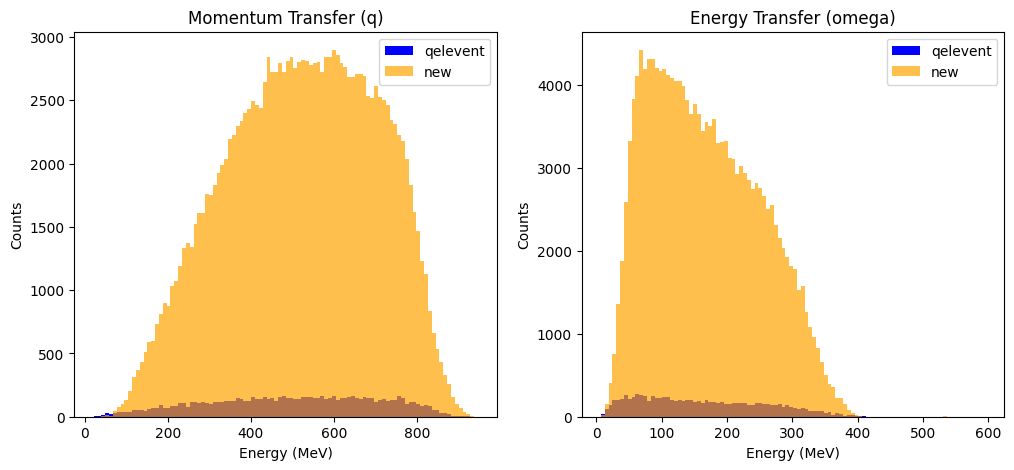

In [134]:
# mom_ins, mom_outs, q_vals, omega_vals = modules.loadroot.load_events_file("../nuwro/eventsout.root")
mom_ins, mom_outs, q_vals, omega_vals, weights = modules.loadroot.load_events_file("../nuwro/eventsout.root")
# importlib.reload(modules.loadroot)
# importlib.reload(modules.loaddata)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

bins = np.histogram(np.hstack([q_vals_qel, q_vals]), bins=100)[1]
ax[0].hist(q_vals_qel, bins=bins, alpha=1, label="qelevent", color="blue")
ax[0].hist(q_vals, bins=bins, alpha=0.7, label="new", color="orange")

bins = np.histogram(np.hstack([omega_vals_qel, omega_vals]), bins=100)[1]
ax[1].hist(omega_vals_qel, bins=bins, alpha=1, label="qelevent", color="blue")
ax[1].hist(omega_vals, bins=bins, alpha=0.7, label="new", color="orange")

ax[0].legend()
ax[1].legend()

ax[0].set_xlabel("Energy (MeV)")
ax[1].set_xlabel("Energy (MeV)")

ax[0].set_ylabel("Counts")
ax[1].set_ylabel("Counts")

ax[0].set_title("Momentum Transfer (q)")
ax[1].set_title("Energy Transfer (omega)")
None

In [ ]:

# mom_ins, mom_outs, q_vals, omega_vals = modules.loadroot.load_events_file("../nuwro/eventsout.root")
mom_ins_2, mom_outs_2, q_vals_2, omega_vals_2, weights_2 = modules.loadroot.load_events_file("../nuwro/eventsout.root")
# importlib.reload(modules.loadroot)
# importlib.reload(modules.loaddata)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

bins = np.histogram(np.hstack([q_vals_qel, q_vals_2]), bins=100)[1]
ax[0].hist(q_vals_qel, bins=bins, alpha=1, label="qelevent", color="blue")
ax[0].hist(q_vals_2, bins=bins, alpha=0.7, label="new", color="orange")

bins = np.histogram(np.hstack([omega_vals_qel, omega_vals_2]), bins=100)[1]
ax[1].hist(omega_vals_qel, bins=bins, alpha=1, label="qelevent", color="blue")
ax[1].hist(omega_vals_2, bins=bins, alpha=0.7, label="new", color="orange")

ax[0].legend()
ax[1].legend()

ax[0].set_xlabel("Energy (MeV)")
ax[1].set_xlabel("Energy (MeV)")

ax[0].set_ylabel("Counts")
ax[1].set_ylabel("Counts")

ax[0].set_title("Momentum Transfer (q)")
ax[1].set_title("Energy Transfer (omega)")
None

# $q/\omega$ scatterplot

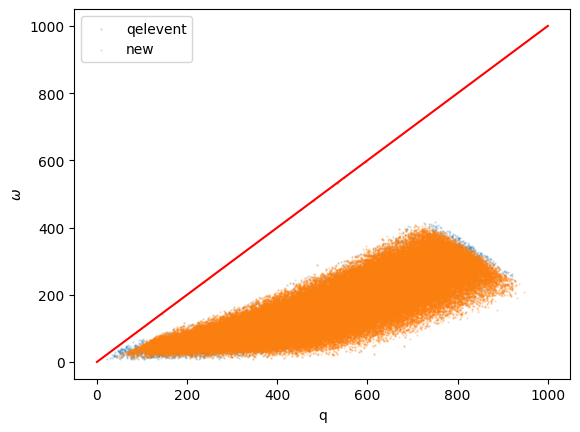

In [135]:
size = 0.5
alpha = 0.2
plt.scatter(q_vals_qel, omega_vals_qel, s=size, alpha=alpha, label="qelevent")
plt.scatter(q_vals, omega_vals, s=size, alpha=alpha, label="new")
plt.plot([0, 1000], [0,1000], color="red")
plt.ylabel("$\\omega$")
plt.xlabel("q")
plt.legend()

# $q$ slice comparison to expected response

In [5]:
# Load lfg data, create interpolator
lfg_q, lfg_data = modules.loaddata.load_response_functions("./data/lfg_week4_data/", "responses_C12_CC_LFG")
funcs = modules.loaddata.build_spectral_interpolator(lfg_q, lfg_data)
t2k_bins, t2k_vals = modules.loaddata.load_t2k("data/t2k/t2kflux_2020_plus250kA_nominal_nd280.txt")


In [ ]:
MeV = 1
GeV = 1000 * MeV
sek = 1 / (6.58211889 * 1E-22 * MeV)
metr = sek / 299792458
meter = metr
millimeter = 0.001 * meter
centimeter = 10 * millimeter
centimeter2 = centimeter ** 2
cm2 = centimeter2
G = 1.16639 * 1E-5 / (GeV * GeV)

/tmp/ipykernel_17141/665782816.py:14: RuntimeWarning: invalid value encountered in sqrt
  k_prim = np.sqrt(eps_prim**2 - m_l**2)


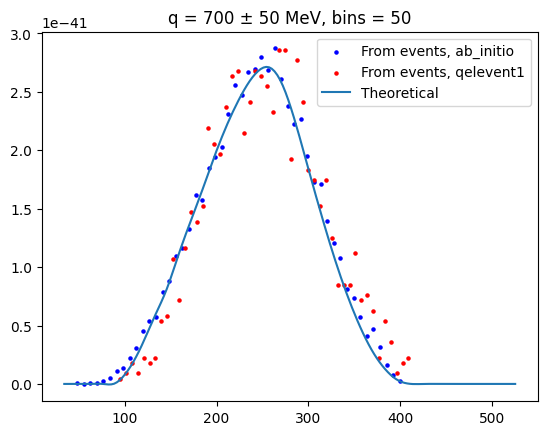

In [156]:
target_q = 700 # q for which to plot
q_delta = 50 # how wide the q slice should be


# Mathematical differential cross section calculation ------
eps = 600 # Beam energy
#muon mass
m_l = 105.66

# omega = test_x
omega = np.linspace(0, 600, 200)
eps_prim = eps - omega
k = eps
k_prim = np.sqrt(eps_prim**2 - m_l**2)

Q_sq = target_q**2 - omega**2

costheta = (k**2 + k_prim**2 - target_q**2) / (2 * k * k_prim)
# costheta = np.arccos(temp)
# costheta = np.nan_to_num(costheta)


v00 = 2 * eps * eps_prim * ( 1 + k_prim/eps_prim * costheta )
vzz = omega**2 / target_q**2 * (m_l ** 2 + v00) + m_l**2 / target_q**2 * (m_l**2 + 2 * omega * (eps + eps_prim) + target_q**2)
v0z = omega / target_q * (m_l**2 + v00) + m_l**2 / target_q * (eps + eps_prim)
vxx = Q_sq + Q_sq * (m_l**2 + v00) / (2 * target_q**2) - m_l**2 / target_q**2 * (m_l**2 / 2 + omega * (eps + eps_prim))
vxy = Q_sq * (eps + eps_prim) / target_q - m_l**2 * omega / target_q
# r00 r0z rzz rxx rxy
coeffs = np.array([v00, -v0z, vzz, vxx, -vxy])

nrf_vals = np.array([
    funcs[0]((target_q, omega)),
    funcs[1]((target_q, omega)),
    funcs[2]((target_q, omega)),
    funcs[3]((target_q, omega)),
    funcs[4]((target_q, omega)),
])
cross_section = np.nan_to_num(np.sum(nrf_vals * coeffs, axis=0)) * G**2 / (8 * np.pi**2) * (k_prim) / (eps) / cm2

# Differential cross section from events ------
bincount = 50

def plot_xsec_from_events(qvals, wvals, label, colour, avgweight):
    mask = np.abs(qvals - target_q) < q_delta

    counts, bins = np.histogram(wvals[mask], bins=bincount)
    dq = q_delta * 2
    dw = bins[1] - bins[0]

    xsec = avgweight * counts / (1) / len(qvals)

    plt.scatter(bins[:-1], xsec, label=f"From events, {label}", color=colour, s=5)

plot_xsec_from_events(q_vals, omega_vals, "ab_initio", "blue", weights[0])
plot_xsec_from_events(q_vals_qel, omega_vals_qel, "qelevent1", "red", weights_qel[0])

# normcounts = counts / np.max(counts)
plt.Figure(figsize=(10,6), dpi=300)


# plt.plot(omega + 34, cross_section / (np.max(cross_section)), label="In python")
plt.plot(omega + 34, cross_section, label="Theoretical")
# plt.plot(test_x + 34, test_y / np.max(test_y), label="From nuwro", linestyle="dashed")
# for cidx in range(5):
#     plt.plot(lfg_data[lfg_idx, cidx, 0], lfg_data[lfg_idx, cidx, 1] / np.max(np.abs(lfg_data[lfg_idx, cidx, 1])) * 0.5, label=f"NRF {cidx}")
# plt.bar(bins[:-1], normcounts, width=np.diff(bins), alpha=0.5, label="Events")

plt.title(f"q = {target_q} ± {q_delta} MeV, bins = {bincount}")
plt.legend()
# plt.xlim(0, 400)
# plt.ylim(-0.01, 0.01)

# NuWro T2K Beam profile

In [9]:
import scipy.interpolate
stepsize = 10
coordx = []
coordy = []
for i in range(len(t2k_bins)):
    xcoord = (t2k_bins[i][0] + t2k_bins[i][1]) / 2
    if xcoord > 1500:
        break
    coordx.append(xcoord)
    coordy.append(t2k_vals[i])

xpoints = np.arange(final_min, final_max, stepsize)

ypoints = scipy.interpolate.CubicSpline(coordx, coordy)(xpoints)


datax = []
datay = []
for x, y in zip(t2k_bins, t2k_vals):
    if x[0] > 1500:
        break
    datax.append((x[0]))
    datax.append((x[1]))
    datay.append(y)
    datay.append(y)

plt.figure(figsize=(20,12))
plt.plot(datax, datay / np.max(datay), label="Flux Data", color="black", drawstyle="steps-post", alpha=0.4)
plt.bar(xpoints, ypoints / np.max(ypoints), width=stepsize, label="Beam profile", color="orange")
plt.xlim(0, 1500)
plt.xlabel("Energy (MeV)")
plt.ylabel("Histogram Value (Normalized)")
plt.title("T2K Beam Profile")
plt.legend()

bins = ""
for y in ypoints:
    bins += f"{y/np.max(ypoints)} "

print(f"{np.min(xpoints)} {np.max(xpoints)} {bins}")

NameError: name 'final_min' is not defined

In [17]:
vals = []
vals_qel = []
with open("../nuwro/weights.txt", "r") as f:
    lines = f.readlines()
    for line in lines:
        vals.append(float(line.strip()))
with open("../nuwro/weights_qel.txt", "r") as f:
    lines = f.readlines()
    for line in lines:
        vals_qel.append(float(line.strip()))

vals = np.array(vals)
vals_qel = np.array(vals_qel)
print(np.average(vals), np.std(vals))
print(np.average(vals_qel), np.std(vals_qel))

2.332743263312816e-38 7.844208838953706e-38
4.475129359943338e-39 5.2612451902188116e-39
